In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Connect to database
conn = sqlite3.connect('retail_sales.db')

print(" Connected to database!")
print(" Ready to create visualizations!")

 Connected to database!
 Ready to create visualizations!


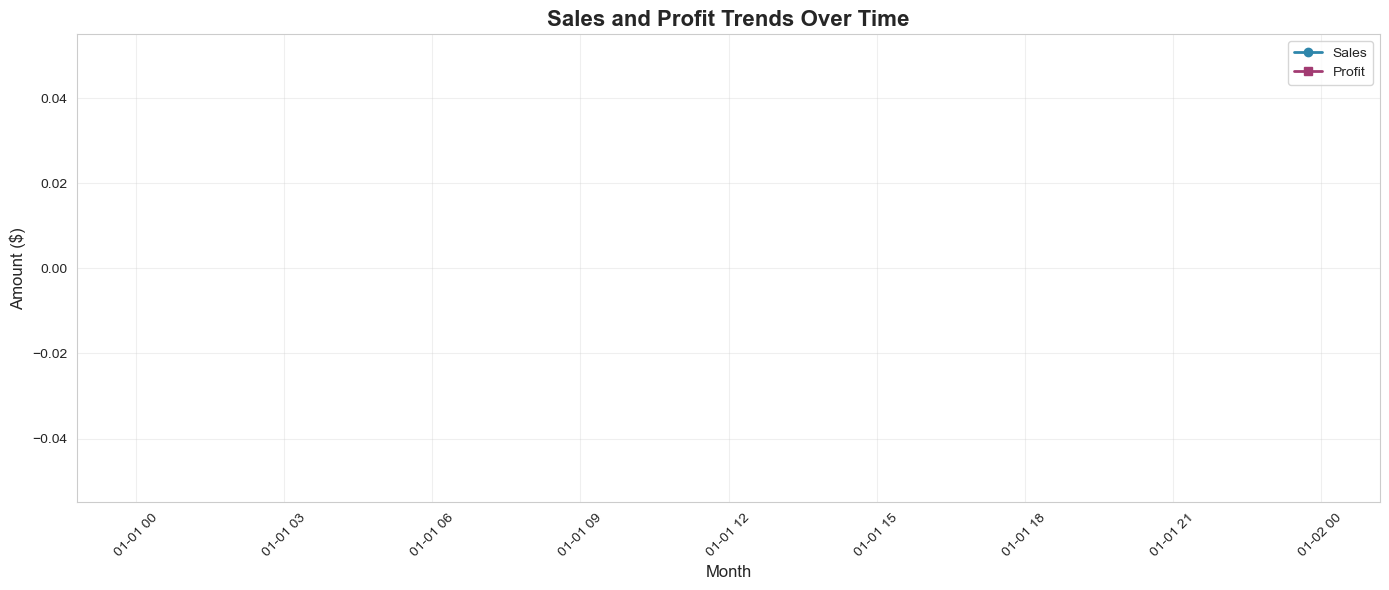

✅ Saved: sales_trend.png


In [4]:
# Query
query = """
SELECT 
    strftime('%Y-%m', "Order Date") as year_month,
    ROUND(SUM(Sales), 2) as total_sales,
    ROUND(SUM(Profit), 2) as total_profit
FROM orders
GROUP BY year_month
ORDER BY year_month;
"""

df = pd.read_sql(query, conn)
df['year_month'] = pd.to_datetime(df['year_month'])

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['year_month'], df['total_sales'], marker='o', linewidth=2, label='Sales', color='#2E86AB')
ax.plot(df['year_month'], df['total_profit'], marker='s', linewidth=2, label='Profit', color='#A23B72')
ax.set_title('Sales and Profit Trends Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Amount ($)', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: sales_trend.png")

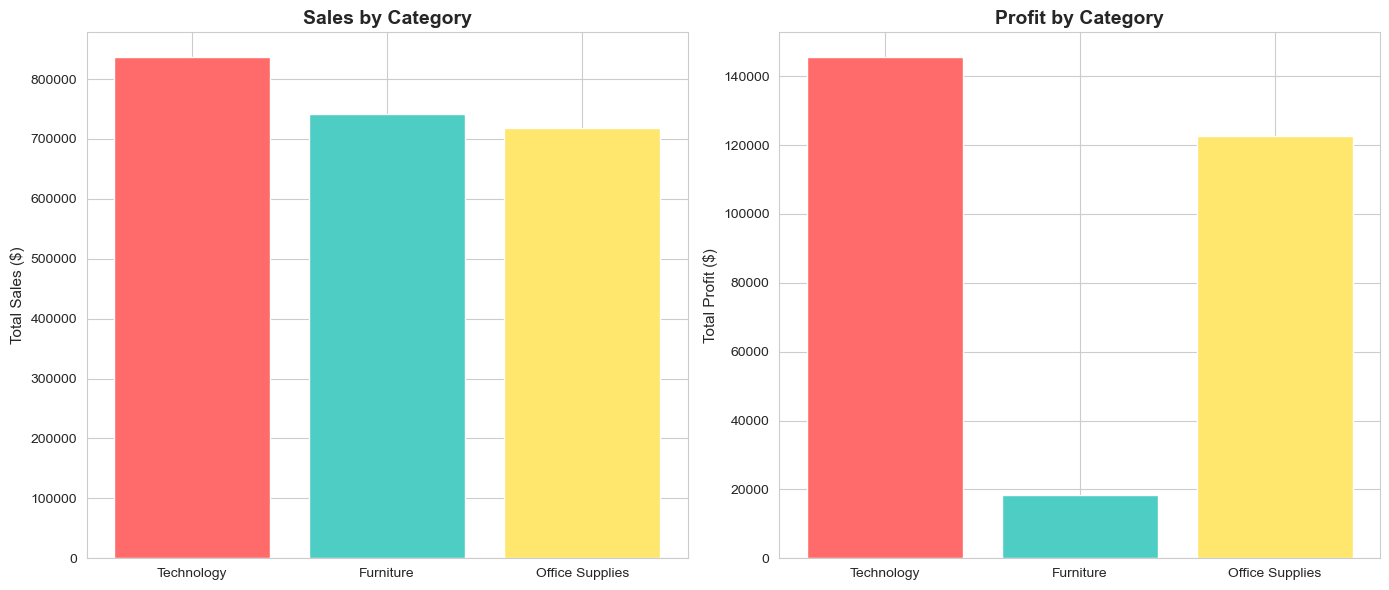

✅ Saved: category_performance.png


In [6]:
# Query
query = """
SELECT 
    Category,
    ROUND(SUM(Sales), 2) as total_sales,
    ROUND(SUM(Profit), 2) as total_profit
FROM orders
GROUP BY Category
ORDER BY total_sales DESC;
"""

df = pd.read_sql(query, conn)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sales by category
axes[0].bar(df['Category'], df['total_sales'], color=['#FF6B6B', '#4ECDC4', '#FFE66D'])
axes[0].set_title('Sales by Category', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)

# Profit by category
axes[1].bar(df['Category'], df['total_profit'], color=['#FF6B6B', '#4ECDC4', '#FFE66D'])
axes[1].set_title('Profit by Category', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Profit ($)', fontsize=11)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('category_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: category_performance.png")

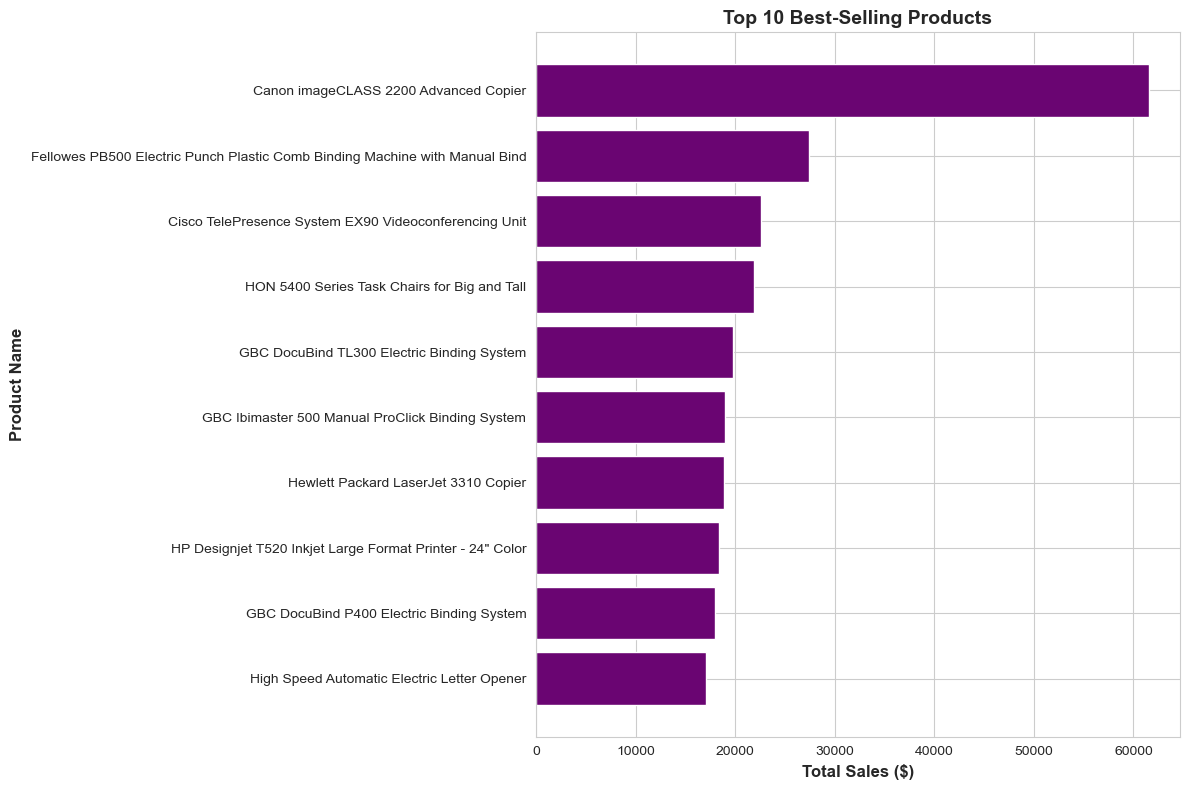

✅ Saved: top_products.png


In [8]:
# Query
query = """
SELECT 
    "Product Name",
    ROUND(SUM(Sales), 2) as total_sales
FROM orders
GROUP BY "Product Name"
ORDER BY total_sales DESC
LIMIT 10;
"""

df = pd.read_sql(query, conn)

# Plot
plt.figure(figsize=(12, 8))
plt.barh(df['Product Name'], df['total_sales'], color='#6A0572')
plt.xlabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')
plt.title('Top 10 Best-Selling Products', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_products.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: top_products.png")

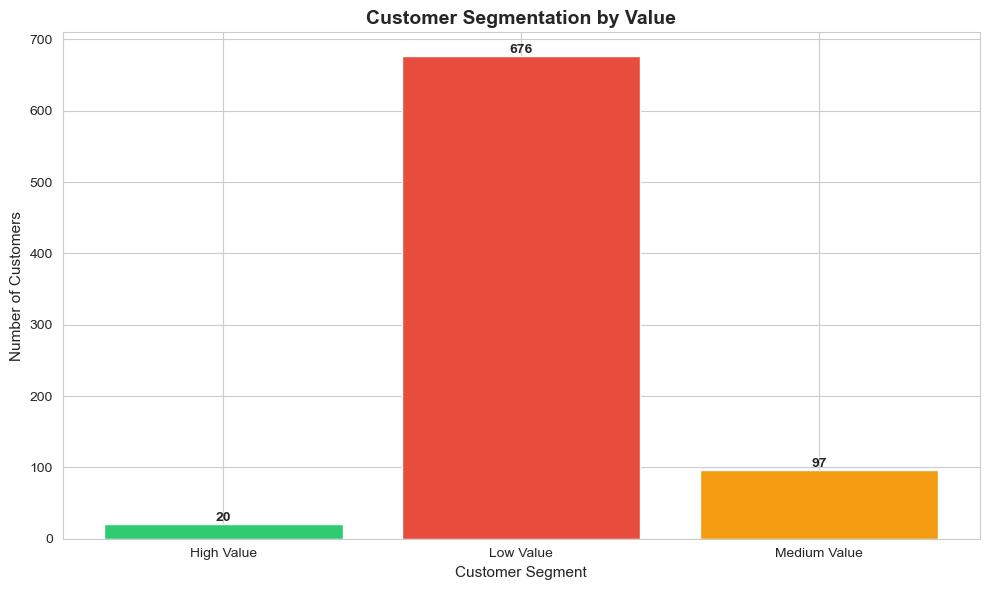

✅ Saved: customer_segments.png


In [10]:
# Query (simplified RFM)
query = """
WITH customer_metrics AS (
    SELECT 
        "Customer Name",
        COUNT(*) as num_orders,
        ROUND(SUM(Sales), 2) as total_spent,
        CASE 
            WHEN SUM(Sales) >= 10000 THEN 'High Value'
            WHEN SUM(Sales) >= 5000 THEN 'Medium Value'
            ELSE 'Low Value'
        END as customer_segment
    FROM orders
    GROUP BY "Customer Name"
)
SELECT 
    customer_segment,
    COUNT(*) as num_customers,
    ROUND(AVG(total_spent), 2) as avg_spent
FROM customer_metrics
GROUP BY customer_segment;
"""

df = pd.read_sql(query, conn)

# Plot
colors = {'High Value': '#2ECC71', 'Medium Value': '#F39C12', 'Low Value': '#E74C3C'}
plt.figure(figsize=(10, 6))
bars = plt.bar(df['customer_segment'], df['num_customers'], 
               color=[colors[seg] for seg in df['customer_segment']])
plt.title('Customer Segmentation by Value', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=11)
plt.xlabel('Customer Segment', fontsize=11)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('customer_segments.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: customer_segments.png")

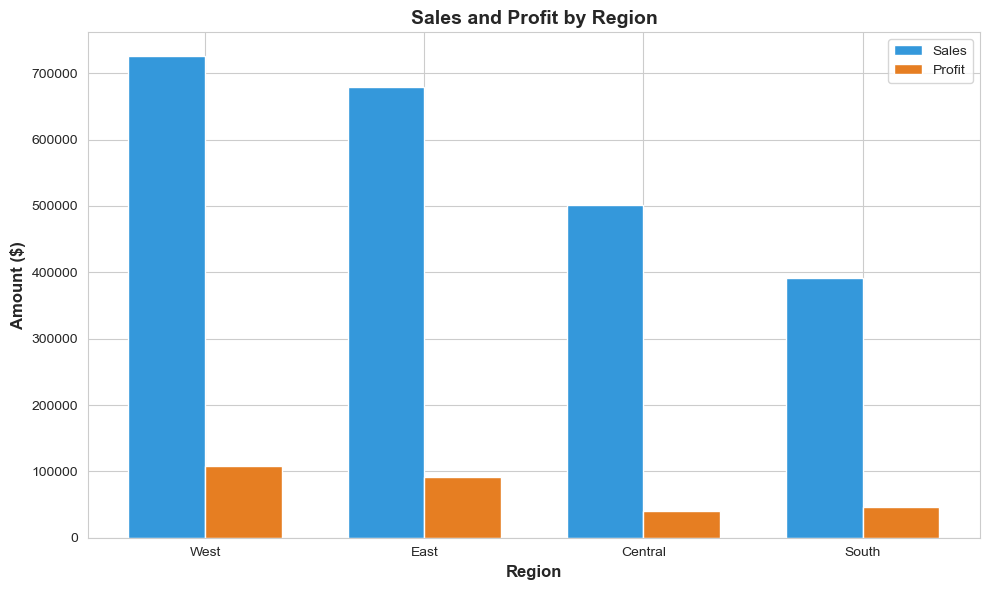

✅ Saved: regional_performance.png


In [12]:
# Query
query = """
SELECT 
    Region,
    ROUND(SUM(Sales), 2) as total_sales,
    ROUND(SUM(Profit), 2) as total_profit
FROM orders
GROUP BY Region
ORDER BY total_sales DESC;
"""

df = pd.read_sql(query, conn)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df['total_sales'], width, label='Sales', color='#3498DB')
bars2 = ax.bar([i + width/2 for i in x], df['total_profit'], width, label='Profit', color='#E67E22')

ax.set_xlabel('Region', fontsize=12, fontweight='bold')
ax.set_ylabel('Amount ($)', fontsize=12, fontweight='bold')
ax.set_title('Sales and Profit by Region', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['Region'])
ax.legend()

plt.tight_layout()
plt.savefig('regional_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: regional_performance.png")

In [14]:
conn.close()